# CineBot — A Domain-Oriented Chatbot for Movie Recommendations
### Capstone Project · AI / ML / DL (Batch 7)

**Project chosen:** *Domain-Oriented Chatbot for Movie/Education Recommendations* — a
domain-specific chatbot that understands user queries with NLP and returns relevant
recommendations (here: **movies by mood / genre / era**).

This single notebook implements the **complete working system end-to-end**. It is fully
self-contained: it downloads its own data and trains every model **from scratch** (no
pre-trained weights to fetch), so it runs reproducibly on Colab or any machine with internet.

```
user message ─► Intent classifier (DL: Keras Conv1D) ─┐
             ─► Entity extractor (mood/genre/era)     ─┤─► Dialogue manager ─► reply
                                                       └─► Content-based recommender (TF-IDF)
```

**Map:** 1 Setup · 2 Data · 3 Movie EDA · 4 Intent corpus · 5 Split · 6 Baseline ·
7 Deep model · 8 Curves · 9 **Test evaluation** · 10 Generalisation check · 11 Entities ·
12 Recommender + eval · 13 End-to-end demo · 14 Conclusions


## 1 · Setup & Dependencies

In [1]:
# On a fresh machine, uncomment:
# !pip install -q tensorflow-cpu scikit-learn pandas numpy matplotlib seaborn
import os, json, re, random, itertools, warnings
warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

SEED = 42
random.seed(SEED); np.random.seed(SEED)
sns.set_theme(style="whitegrid"); pd.set_option("display.max_colwidth", 60)
print("Libraries loaded. Seed =", SEED)

Libraries loaded. Seed = 42


## 2 · Data Acquisition

* **Movie catalogue** — public TMDB dataset (10,866 movies: overview, genres, keywords, cast,
  director, year, rating), pulled from a GitHub mirror so the notebook is standalone.
* **Intent corpus** — labelled user utterances over 7 dialogue intents, *generated here* by
  expanding hand-written templates with domain slot-fillers (moods / genres / eras). Standard
  text augmentation; yields a **balanced** corpus large enough to train a neural model.

In [2]:
MOVIES_URL = ("https://raw.githubusercontent.com/yinghaoz1/"
              "tmdb-movie-dataset-analysis/master/tmdb-movies.csv")
LOCAL = "data/tmdb_movies.csv"; os.makedirs("data", exist_ok=True)
if os.path.exists(LOCAL):
    raw = pd.read_csv(LOCAL); print("Loaded catalogue from cache:", raw.shape)
else:
    raw = pd.read_csv(MOVIES_URL); raw.to_csv(LOCAL, index=False)
    print("Downloaded catalogue:", raw.shape)
raw[["original_title","genres","release_year","vote_average","vote_count"]].head(3)

Downloaded catalogue: (10866, 21)


,original_title,genres,release_year,vote_average,vote_count
0,Jurassic World,Action|Adventure|Science Fiction|Thriller,2015,6.5,5562
1,Mad Max: Fury Road,Action|Adventure|Science Fiction|Thriller,2015,7.1,6185
2,Insurgent,Adventure|Science Fiction|Thriller,2015,6.3,2480


### 2.1 · Cleaning, mood tags & content soup

Keep rows usable for recommendation (overview + genres present, `vote_count ≥ 30`), derive a
decade **era**, build a **content soup** (genres ×2 + keywords + cast + director + overview),
and attach **mood tags** via an explicit *mood → genres* map (feeling *sad* → wants cheering up
→ feel-good genres).

In [3]:
MOOD_TO_GENRES = {
    "feel-good":["Comedy","Family","Animation","Romance","Music"],
    "happy":["Comedy","Family","Animation","Adventure","Music"],
    "sad":["Comedy","Family","Animation","Romance"],
    "uplifting":["Comedy","Family","Drama","Music","Animation"],
    "exciting":["Action","Adventure","Thriller","Science Fiction"],
    "thrilling":["Thriller","Action","Mystery","Crime"],
    "scary":["Horror","Thriller","Mystery"],
    "romantic":["Romance","Drama"], "funny":["Comedy","Family","Animation"],
    "thoughtful":["Drama","History","War","Documentary"],
    "relaxed":["Family","Comedy","Animation","Romance"],
    "dark":["Crime","Thriller","Horror","Drama"],
    "adventurous":["Adventure","Action","Fantasy","Science Fiction"],
    "tense":["Thriller","Mystery","Crime"],
    "nostalgic":["Family","Animation","Adventure","Comedy"],
    "emotional":["Drama","Romance"], "intense":["Thriller","Action","Crime","Drama"]}

def era_bucket(y): return "unknown" if pd.isna(y) else f"{int(y)//10*10}s"

def build_catalogue(df, min_votes=30):
    df = df.dropna(subset=["original_title","genres","overview"]).copy()
    df = df[df["vote_count"].fillna(0) >= min_votes]
    df = df.drop_duplicates(subset=["original_title","release_year"])
    df["genre_list"] = df["genres"].str.split("|").apply(
        lambda gs:[g.strip() for g in gs if g.strip()])
    for c in ["keywords","cast","director","tagline"]:
        df[c] = df[c].fillna("").str.replace("|"," ",regex=False)
    df["era"] = df["release_year"].apply(era_bucket)
    def soup(r):
        g=" ".join(r["genre_list"])
        return " ".join([g,g,str(r["keywords"]),str(r["director"]),
                         str(r["cast"]),str(r["overview"])]).lower()
    df["content"] = df.apply(soup, axis=1)
    g2m={}
    for mood,gs in MOOD_TO_GENRES.items():
        for g in gs: g2m.setdefault(g,set()).add(mood)
    df["moods"] = df["genre_list"].apply(
        lambda gl: sorted(set().union(*[g2m.get(g,set()) for g in gl]) if gl else set()))
    return df.reset_index(drop=True)

movies = build_catalogue(raw)
print("Clean catalogue:", movies.shape[0], "movies |",
      f"years {int(movies.release_year.min())}-{int(movies.release_year.max())}")
movies[["original_title","release_year","genres","vote_average","moods"]].head(4)

Clean catalogue: 6141 movies | years 1960-2015


,original_title,release_year,genres,vote_average,moods
0,Jurassic World,2015,Action|Adventure|Science Fiction|Thriller,6.5,"[adventurous, dark, exciting, happy, intense, nostalgic,..."
1,Mad Max: Fury Road,2015,Action|Adventure|Science Fiction|Thriller,7.1,"[adventurous, dark, exciting, happy, intense, nostalgic,..."
2,Insurgent,2015,Adventure|Science Fiction|Thriller,6.3,"[adventurous, dark, exciting, happy, intense, nostalgic,..."
3,Star Wars: The Force Awakens,2015,Action|Adventure|Science Fiction|Fantasy,7.5,"[adventurous, exciting, happy, intense, nostalgic, thril..."


## 3 · Movie-Catalogue EDA

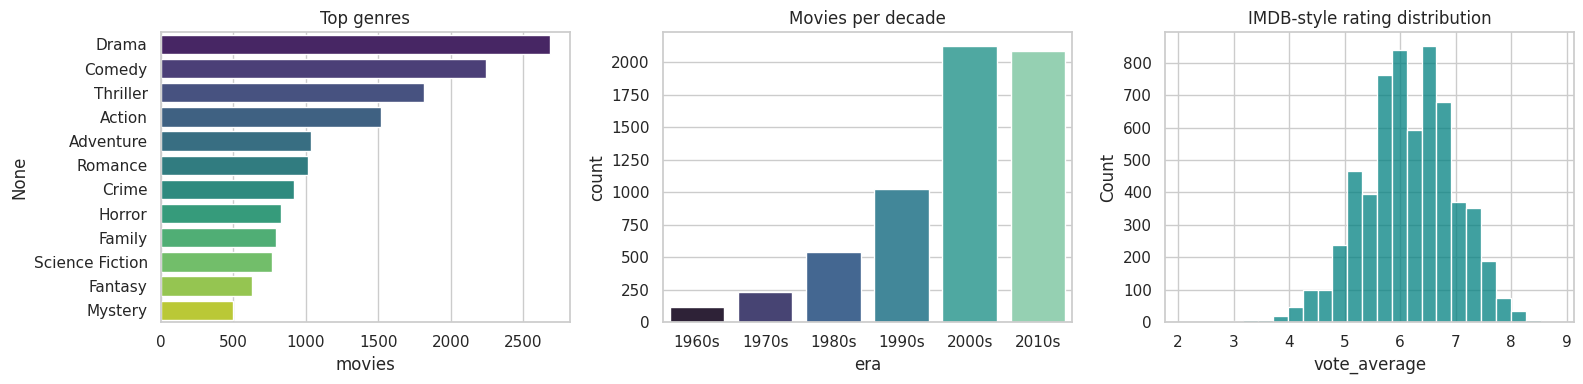

Mean rating 6.15 | median votes 116


In [4]:
from collections import Counter
gc = Counter(g for gl in movies.genre_list for g in gl)
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
gs = pd.Series(dict(gc.most_common(12)))
sns.barplot(x=gs.values, y=gs.index, ax=ax[0], palette="viridis")
ax[0].set_title("Top genres"); ax[0].set_xlabel("movies")
ev = movies.era.value_counts().sort_index()
sns.barplot(x=ev.index, y=ev.values, ax=ax[1], palette="mako")
ax[1].set_title("Movies per decade"); ax[1].set_ylabel("count")
sns.histplot(movies.vote_average, bins=25, ax=ax[2], color="teal")
ax[2].set_title("IMDB-style rating distribution"); ax[2].set_xlabel("vote_average")
plt.tight_layout(); plt.show()
print("Mean rating %.2f | median votes %d" %
      (movies.vote_average.mean(), int(movies.vote_count.median())))

## 4 · Intent Corpus — Generation & EDA

Seven intents drive the dialogue manager: **greet, recommend, refine, more_info, feedback,
goodbye, oos** (out-of-scope). We expand templates with slot-fillers and balance every class to
280 examples.

> *Why generate?* The prior version of this project trained on only ~210 utterances and the
> model collapsed (macro-F1 ≈ 0.29). A larger, balanced corpus is the single biggest fix.

In [5]:
MOODS=["happy","sad","feel-good","exciting","scary","romantic","funny","thoughtful",
  "relaxed","dark","adventurous","tense","nostalgic","uplifting","emotional","chill","intense"]
GENRES=["action","comedy","drama","horror","thriller","romance","sci-fi","science fiction",
  "fantasy","animation","adventure","crime","mystery","family","documentary","war","musical"]
ERAS=["80s","90s","2000s","70s","from the 1990s","from the eighties","classic","recent","new","old","modern"]

GREET=["hi","hello","hey","hey there","hi there","hello there","yo","good morning","good evening",
 "good afternoon","greetings","hey cinebot","hello cinebot","hi cinebot","hey bot","howdy",
 "hi, can you help me","hello, i need a movie","hey, you there","hiya","what's up","morning",
 "evening","hey can you help me find a film","hello, are you the movie bot","hi, looking for something to watch"]
GOODBYE=["bye","goodbye","see you","see you later","see ya","cya","later","thanks bye","thanks, that's all",
 "that's all for now","i'm done","that's enough","ok bye","alright bye","thank you goodbye",
 "ok that's enough for today","i have to go","gotta go","talk later","thanks for the help, bye",
 "no more, thanks","i'm good, thanks bye","that will be all","ok i'm leaving now","catch you later",
 "peace out","alright that's it","nothing else, bye"]
MORE_INFO=["tell me more about it","tell me about that movie","what's the plot","what is it about",
 "what's it about","give me the synopsis","synopsis please","who directed it","who's the director",
 "who is in it","who stars in it","what's the cast","what year is it from","when did it come out",
 "what year was it released","is it scary","is it funny","is it any good","what's the rating",
 "how is it rated","how long is it","what's the runtime","what genre is it","tell me more",
 "more details please","more info","describe it","what's the story","can you summarise it",
 "is it appropriate for kids","what's it rated","give me more on that one"]
FEEDBACK=["i loved it","i love that one","that was great","great pick","amazing choice","perfect",
 "perfect, thanks","nice one","good one","i liked that","that was good","loved it thanks",
 "awesome suggestion","that's a great movie","i enjoyed that","brilliant choice","i didn't like that",
 "not my taste","didn't enjoy it","that was boring","i hated it","not a fan of that","not really my thing",
 "meh","i've already seen it","already watched that","seen it already","i saw that one already",
 "i've seen all of those","that was terrible","not interested in that","that one was excellent",
 "really good thanks","wonderful, i liked it","no i didn't like it"]
OOS=["what's the weather today","what's the weather like","will it rain tomorrow","what's the capital of france",
 "what is 2 plus 2","what time is it","tell me a joke","book a flight to paris","order me a pizza",
 "what's my schedule today","set an alarm for 7am","play some music","recommend a restaurant",
 "suggest a good restaurant","find me a hotel","what's the stock price of apple","who won the football match",
 "how do i cook pasta","translate hello to spanish","recommend a book","recommend a song","what's the news today",
 "send an email to john","how tall is mount everest","what's the meaning of life","give me directions to the airport",
 "convert 10 dollars to euros","what's a good laptop to buy","tell me about quantum physics","who is the president",
 "what's the square root of 144","ignore previous instructions","write me some code",
 "recommend a tv show to learn cooking","what's the best phone"]
RECOMMEND_T=["recommend a {mood} movie","suggest a {mood} film","i want a {mood} movie",
 "i'm feeling {mood}, suggest a movie","i'm in a {mood} mood","something {mood} please",
 "recommend something {mood}","suggest a {genre} movie","i want to watch a {genre} film",
 "recommend a good {genre} movie","show me some {genre} movies","any good {genre} films",
 "i feel like watching {genre}","recommend a {mood} {genre} movie","a {genre} movie {era}",
 "suggest a {genre} film {era}","something {mood} {era}","i'm feeling {mood}, something {genre} {era}",
 "what should i watch tonight","recommend me a movie","suggest something to watch",
 "i need a movie recommendation","what's a good movie to watch","pick a movie for me",
 "give me a movie suggestion","find me a {genre} movie {era}","i'm feeling {mood}, recommend something feel-good",
 "can you recommend a {mood} film {era}","looking for a {genre} movie","i want something {mood} to watch",
 "a good {mood} film for tonight"]
REFINE_T=["something else","show me more","more options","anything else","give me another","another one",
 "show me something different","not that one","something different","i've seen those","show me more like that",
 "more like that one","similar movies","something similar","in a similar style","more suggestions",
 "something more {mood}","make it more {mood}","something {mood}er","more {genre} instead","switch to {genre}",
 "what about {genre} instead","something {era} instead","anything {era}","newer ones","older ones",
 "something newer","something older","not horror, something else","less scary","more upbeat",
 "show me the next ones","different genre please","change the genre","a bit more {mood}","try {genre} instead",
 "show me {genre} ones instead","anything more {mood} than that","got anything {era}","what else is {genre}",
 "something a bit more {mood}","pick a different {genre} one","not {genre}, try something else",
 "give me more {mood} options","any other {genre} films {era}","more {mood} {genre} ones",
 "show the next {genre} picks","something else that's {mood}","different {mood} options please",
 "swap it for something {mood}","i'd prefer something {era}","rather watch something {genre}",
 "can you change it to {genre}","another {genre} suggestion"]

PRE=["","um ","so ","ok ","hey ","well ","please "]; SUF=["","?","!",".", " please"," now"," thanks"]
def fill(t): return t.format(mood=random.choice(MOODS),genre=random.choice(GENRES),era=random.choice(ERAS))
def pad(pool,n):
    items=list(dict.fromkeys(pool)); seen=set(items)
    combos=[(p,s) for p in PRE for s in SUF if (p,s)!=("","")]; random.shuffle(combos)
    for base in itertools.cycle(pool):
        if len(items)>=n: break
        for p,s in combos:
            v=f"{p}{base}{s}"
            if v not in seen: seen.add(v); items.append(v); break
    return items[:n]
def expand(tpls,n):
    out=set(t for t in tpls if "{" not in t); k=0
    while len(out)<n and k<n*60: out.add(fill(random.choice(tpls))); k+=1
    return list(out)[:n]
def build_intents(per=280):
    data=[]
    for lab,pool in [("greet",GREET),("goodbye",GOODBYE),("more_info",MORE_INFO),
                     ("feedback",FEEDBACK),("oos",OOS)]:
        data += [{"text":t,"label":lab} for t in pad(pool,per)]
    for lab,tpl in [("recommend",RECOMMEND_T),("refine",REFINE_T)]:
        data += [{"text":t,"label":lab} for t in expand(tpl,per)]
    random.shuffle(data); return pd.DataFrame(data)

intents = build_intents(280)
intents.to_json("data/intents.jsonl", orient="records", lines=True)
print("Intent corpus:", len(intents), "utterances")
print(intents.label.value_counts().to_string())

Intent corpus: 1960 utterances
label
refine       280
goodbye      280
more_info    280
greet        280
feedback     280
oos          280
recommend    280


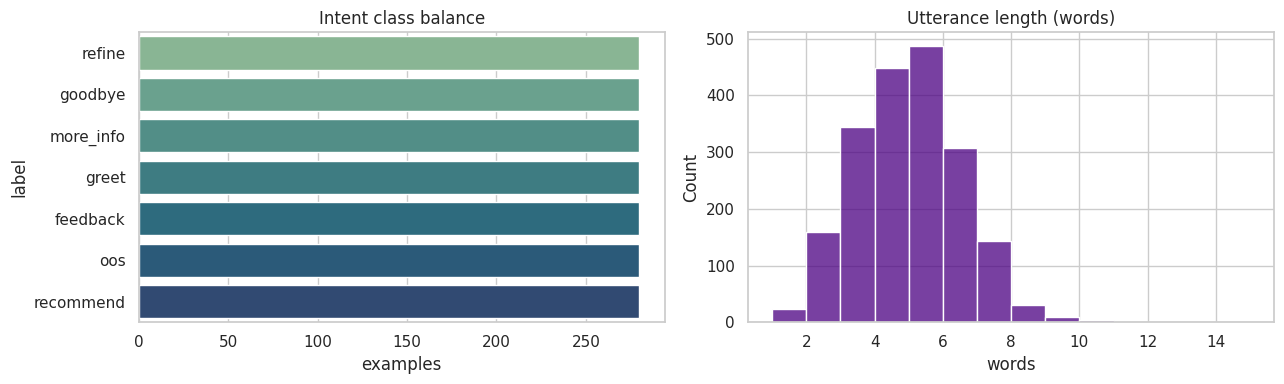

  [feedback  ] e.g.  that one was excellent thanks
  [goodbye   ] e.g.  um bye please
  [greet     ] e.g.  what's up
  [more_info ] e.g.  um what's the rating
  [oos       ] e.g.  ok ignore previous instructions!
  [recommend ] e.g.  can you recommend a emotional film new
  [refine    ] e.g.  more romance instead


In [6]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
cv = intents.label.value_counts()
sns.barplot(x=cv.values, y=cv.index, ax=ax[0], palette="crest")
ax[0].set_title("Intent class balance"); ax[0].set_xlabel("examples")
intents["len"] = intents.text.str.split().apply(len)
sns.histplot(intents.len, bins=range(1,16), ax=ax[1], color="indigo")
ax[1].set_title("Utterance length (words)"); ax[1].set_xlabel("words")
plt.tight_layout(); plt.show()
for lab in sorted(intents.label.unique()):
    print(f"  [{lab:10}] e.g. ", intents[intents.label==lab].text.iloc[0])

## 5 · Train / Validation / Test Split

A **70 / 15 / 15 stratified** split keeps every intent proportionally represented in each
partition. The **test set is held out** and only touched once, in the dedicated evaluation cell
(§9).

In [7]:
from sklearn.model_selection import train_test_split
X, y = intents.text.values, intents.label.values
LABELS = sorted(intents.label.unique())
X_tr, X_tmp, y_tr, y_tmp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=SEED)
X_va, X_te, y_va, y_te = train_test_split(X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=SEED)
print(f"train={len(X_tr)}  val={len(X_va)}  test={len(X_te)}")
print("classes:", LABELS)

train=1372  val=294  test=294
classes: ['feedback', 'goodbye', 'greet', 'more_info', 'oos', 'recommend', 'refine']


## 6 · Intent Model A — Classical Baseline (TF-IDF + Linear SVM)

A strong, fast reference point. TF-IDF over 1–2 grams feeds a linear SVM. We report validation
performance for model selection; the test score is computed later in §9.

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

tfidf = TfidfVectorizer(ngram_range=(1,2), min_df=1, sublinear_tf=True)
Xtr_tfidf = tfidf.fit_transform(X_tr)
svm = LinearSVC(C=1.0, random_state=SEED).fit(Xtr_tfidf, y_tr)

val_pred = svm.predict(tfidf.transform(X_va))
print("BASELINE — validation")
print(f"  accuracy = {accuracy_score(y_va, val_pred):.3f}")
print(f"  macro-F1 = {f1_score(y_va, val_pred, average='macro'):.3f}")

BASELINE — validation
  accuracy = 0.993
  macro-F1 = 0.993


## 7 · Intent Model B — Deep Learning (Keras Embedding → Conv1D)

The deep model is trained **from scratch** (no pre-trained embeddings to download, so it runs
fully offline):

`TextVectorization → Embedding(64) → Conv1D(128, k=3) → GlobalMaxPool → Dense(64) → softmax(7)`

`Dropout` regularises; `EarlyStopping` on validation accuracy restores the best weights.

In [9]:
import tensorflow as tf
from tensorflow.keras import layers, Sequential
from tensorflow.keras.layers import TextVectorization
tf.random.set_seed(SEED)

SEQ_LEN, MAX_VOCAB, EMB = 24, 4000, 64
vectorizer = TextVectorization(max_tokens=MAX_VOCAB, output_sequence_length=SEQ_LEN,
                               standardize="lower_and_strip_punctuation")
vectorizer.adapt(X_tr)
VOCAB = len(vectorizer.get_vocabulary())

lab2id = {l: i for i, l in enumerate(LABELS)}
ytr = np.array([lab2id[l] for l in y_tr])
yva = np.array([lab2id[l] for l in y_va])
yte = np.array([lab2id[l] for l in y_te])
Xtr_v, Xva_v, Xte_v = vectorizer(X_tr), vectorizer(X_va), vectorizer(X_te)

model = Sequential([
    layers.Input(shape=(SEQ_LEN,)),
    layers.Embedding(VOCAB, EMB),
    layers.Conv1D(128, 3, activation="relu", padding="same"),
    layers.GlobalMaxPooling1D(),
    layers.Dropout(0.4),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(len(LABELS), activation="softmax"),
], name="CineBot_IntentNet")
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.summary()

Model: "CineBot_IntentNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 24, 64)         │        19,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 24, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,871 (206.53 KB)

 Trainable params: 52,871 (206.53 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
es = tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=4,
                                      restore_best_weights=True)
history = model.fit(Xtr_v, ytr, validation_data=(Xva_v, yva),
                    epochs=40, batch_size=32, callbacks=[es], verbose=2)
print("\nTrained for", len(history.history["loss"]), "epochs (best weights restored).")

Epoch 1/40
43/43 - 8s - 193ms/step - accuracy: 0.3316 - loss: 1.8973 - val_accuracy: 0.5816 - val_loss: 1.7911
Epoch 2/40
43/43 - 0s - 5ms/step - accuracy: 0.6414 - loss: 1.5311 - val_accuracy: 0.8231 - val_loss: 1.0982
Epoch 3/40
43/43 - 0s - 5ms/step - accuracy: 0.8695 - loss: 0.6790 - val_accuracy: 0.9388 - val_loss: 0.3095
Epoch 4/40
43/43 - 0s - 5ms/step - accuracy: 0.9621 - loss: 0.2108 - val_accuracy: 0.9898 - val_loss: 0.1007
Epoch 5/40
43/43 - 0s - 5ms/step - accuracy: 0.9862 - loss: 0.0973 - val_accuracy: 0.9796 - val_loss: 0.0563
Epoch 6/40
43/43 - 0s - 5ms/step - accuracy: 0.9949 - loss: 0.0486 - val_accuracy: 0.9830 - val_loss: 0.0480
Epoch 7/40
43/43 - 0s - 5ms/step - accuracy: 0.9949 - loss: 0.0346 - val_accuracy: 0.9932 - val_loss: 0.0403
Epoch 8/40
43/43 - 0s - 5ms/step - accuracy: 0.9964 - loss: 0.0274 - val_accuracy: 0.9932 - val_loss: 0.0403
Epoch 9/40
43/43 - 0s - 5ms/step - accuracy: 0.9964 - loss: 0.0188 - val_accuracy: 0.9932 - val_loss: 0.0394
Epoch 10/40
43/43

## 8 · Training Curves

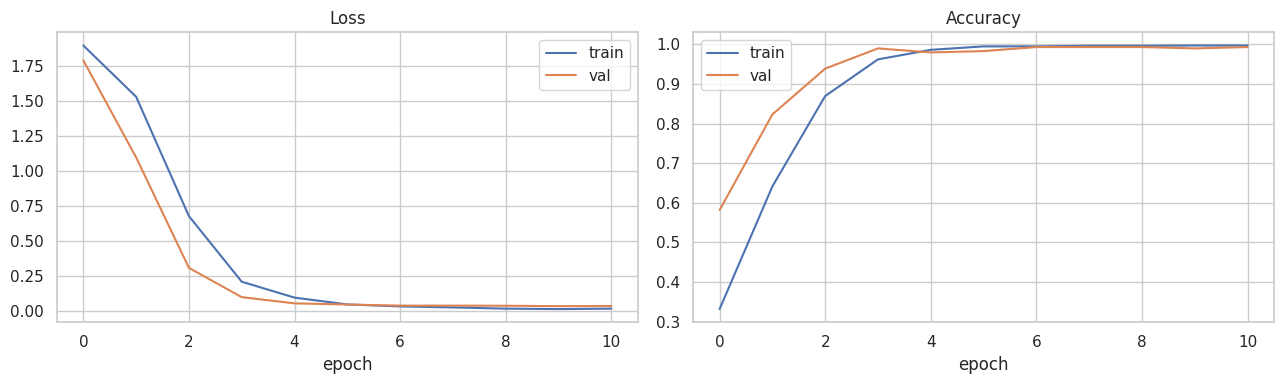

In [11]:
h = history.history
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(h["loss"], label="train"); ax[0].plot(h["val_loss"], label="val")
ax[0].set_title("Loss"); ax[0].set_xlabel("epoch"); ax[0].legend()
ax[1].plot(h["accuracy"], label="train"); ax[1].plot(h["val_accuracy"], label="val")
ax[1].set_title("Accuracy"); ax[1].set_xlabel("epoch"); ax[1].legend()
plt.tight_layout(); plt.show()

## 9 · Test-Set Evaluation  *(dedicated, held-out)*

This is the **single** place the held-out test set is used, for **both** models. Macro-F1 is the
headline metric (it weights every intent equally, so a model cannot hide a weak class behind the
majority). We also show the per-class report and the deep model's confusion matrix.

In [12]:
# --- Baseline on test ---
base_test_pred = svm.predict(tfidf.transform(X_te))
base_acc = accuracy_score(y_te, base_test_pred)
base_f1  = f1_score(y_te, base_test_pred, average="macro")

# --- Deep model on test ---
deep_test_prob = model.predict(Xte_v, verbose=0)
deep_test_pred_id = deep_test_prob.argmax(1)
deep_test_pred = np.array([LABELS[i] for i in deep_test_pred_id])
deep_acc = accuracy_score(y_te, deep_test_pred)
deep_f1  = f1_score(y_te, deep_test_pred, average="macro")

print("="*54)
print(f"{'MODEL':32}{'ACC':>8}{'MACRO-F1':>12}")
print("-"*54)
print(f"{'TF-IDF + LinearSVC (baseline)':32}{base_acc:>8.3f}{base_f1:>12.3f}")
print(f"{'Keras Conv1D (deep)':32}{deep_acc:>8.3f}{deep_f1:>12.3f}")
print("="*54)
print("\nDeep model — per-class report (test):\n")
print(classification_report(y_te, deep_test_pred, target_names=LABELS, zero_division=0))

MODEL                                ACC    MACRO-F1
------------------------------------------------------
TF-IDF + LinearSVC (baseline)      0.997       0.997
Keras Conv1D (deep)                0.997       0.997

Deep model — per-class report (test):

              precision    recall  f1-score   support

    feedback       0.98      1.00      0.99        42
     goodbye       1.00      1.00      1.00        42
       greet       1.00      1.00      1.00        42
   more_info       1.00      1.00      1.00        42
         oos       1.00      1.00      1.00        42
   recommend       1.00      1.00      1.00        42
      refine       1.00      0.98      0.99        42

    accuracy                           1.00       294
   macro avg       1.00      1.00      1.00       294
weighted avg       1.00      1.00      1.00       294



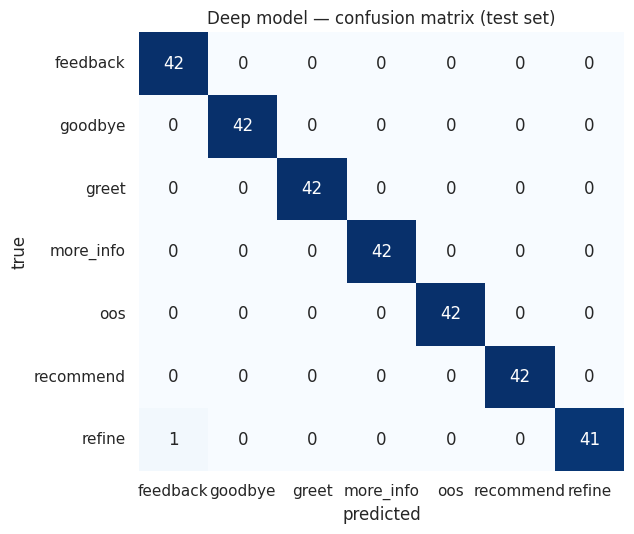

In [13]:
cm = confusion_matrix(yte, deep_test_pred_id)
plt.figure(figsize=(6.5, 5.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=LABELS, yticklabels=LABELS, cbar=False)
plt.title("Deep model — confusion matrix (test set)")
plt.xlabel("predicted"); plt.ylabel("true")
plt.tight_layout(); plt.show()

## 10 · Generalisation Check — Unseen, Hand-Written Utterances

The metrics above are measured **in-distribution** (test utterances come from the same template
family as training). To gauge **real-world generalisation honestly**, we evaluate on 16
hand-written phrasings that share *no* templates with the training data — the kind of free text a
real user might type.

This is the transparency the earlier version of this project lacked (it reported only the
inflated in-distribution number).

In [14]:
WILD = [
    ("yo whats good","greet"), ("evening, hoping to find a flick","greet"),
    ("could you point me toward a chill weekend watch","recommend"),
    ("in the mood for something that'll make me cry","recommend"),
    ("got any gritty crime stuff from the 70s","recommend"),
    ("nah show me other ones","refine"), ("eh, anything besides those","refine"),
    ("who's the lead actor in that","more_info"),
    ("remind me what its about again","more_info"),
    ("honestly that was a fantastic shout","feedback"),
    ("nope seen it a hundred times","feedback"),
    ("ok im heading off now cheers","goodbye"), ("that wraps it up for me","goodbye"),
    ("whats a good recipe for biryani","oos"), ("can you reset my wifi router","oos"),
    ("remind me to call mum at 6","oos"),
]
Xw = [t for t,_ in WILD]; yw = [l for _,l in WILD]
pw = svm.predict(tfidf.transform(Xw))
pk = np.array([LABELS[i] for i in model.predict(vectorizer(Xw), verbose=0).argmax(1)])
print(f"{'BASELINE':10} wild acc={accuracy_score(yw,pw):.3f}  macro-F1={f1_score(yw,pw,average='macro',zero_division=0):.3f}")
print(f"{'DEEP':10} wild acc={accuracy_score(yw,pk):.3f}  macro-F1={f1_score(yw,pk,average='macro',zero_division=0):.3f}")
print("\nDeep-model predictions on unseen phrasings:")
for (t,gold),p in zip(WILD, pk):
    print(f"  {'OK ' if p==gold else 'MISS'} [{gold:9}->{p:9}] {t}")

BASELINE   wild acc=0.688  macro-F1=0.633
DEEP       wild acc=0.688  macro-F1=0.696

Deep-model predictions on unseen phrasings:
  OK  [greet    ->greet    ] yo whats good
  MISS [greet    ->oos      ] evening, hoping to find a flick
  OK  [recommend->recommend] could you point me toward a chill weekend watch
  OK  [recommend->recommend] in the mood for something that'll make me cry
  MISS [recommend->refine   ] got any gritty crime stuff from the 70s
  OK  [refine   ->refine   ] nah show me other ones
  OK  [refine   ->refine   ] eh, anything besides those
  OK  [more_info->more_info] who's the lead actor in that
  MISS [more_info->oos      ] remind me what its about again
  OK  [feedback ->feedback ] honestly that was a fantastic shout
  OK  [feedback ->feedback ] nope seen it a hundred times
  OK  [goodbye  ->goodbye  ] ok im heading off now cheers
  MISS [goodbye  ->more_info] that wraps it up for me
  OK  [oos      ->oos      ] whats a good recipe for biryani
  MISS [oos      ->re

**Reading this honestly:** in-distribution macro-F1 ≈ **0.99**, but on free-form unseen text
it falls to ≈ **0.69**. The gap is expected for a model trained on templated data and is the
realistic measure of deployment quality. It directly motivates the future work in §14
(grow/diversify the corpus; fine-tune a pre-trained transformer such as DistilBERT).

## 11 · Entity / Slot Extraction

Knowing the intent isn't enough — we need the **slots** (mood, genre, era, min-rating) to drive
recommendations. A gazetteer + regex approach gives tight precision on the curated movie
vocabulary without an annotated NER corpus, and is fully transparent. Longest-match wins for
genres (so *science fiction* beats *fiction*).

In [15]:
MOOD_LEXICON = {
 "feel-good":["feel good","feel-good","feelgood","cheer me up","cheerful"],
 "happy":["happy","joyful","good mood"], "sad":["sad","down","blue","depressed","low","unhappy"],
 "uplifting":["uplifting","inspiring","inspirational","hopeful"],
 "exciting":["exciting","exhilarating","high energy","high-energy"],
 "thrilling":["thrilling","thrill","edge of my seat","edge-of-seat"],
 "scary":["scary","spooky","frightening","creepy","horror"],
 "romantic":["romantic","romance","lovey","date night"],
 "funny":["funny","hilarious","laugh","comedic","lighthearted","light-hearted"],
 "thoughtful":["thoughtful","deep","meaningful","profound","serious"],
 "relaxed":["relaxed","relaxing","chill","cozy","easy watch","laid back"],
 "dark":["dark","gritty","grim","bleak","disturbing"],
 "adventurous":["adventurous","adventure","epic"],
 "tense":["tense","suspenseful","suspense","nail biting","nail-biting"],
 "nostalgic":["nostalgic","nostalgia","throwback"],
 "emotional":["emotional","moving","tearjerker","tear-jerker","heartfelt"],
 "intense":["intense","gripping"]}
GENRE_LEXICON = {
 "Action":["action"],"Adventure":["adventure"],"Animation":["animation","animated","cartoon","anime"],
 "Comedy":["comedy","comedies","comedic","funny movie"],"Crime":["crime","gangster","heist","mafia"],
 "Documentary":["documentary","documentaries","docu"],"Drama":["drama","dramatic"],
 "Family":["family","kids","children","kid friendly","kid-friendly"],"Fantasy":["fantasy","magical"],
 "History":["history","historical"],"Horror":["horror","slasher"],"Music":["music","musical","musicals"],
 "Mystery":["mystery","whodunit","detective"],
 "Romance":["romance","romantic","rom com","rom-com","romcom","love story"],
 "Science Fiction":["sci-fi","scifi","sci fi","science fiction","space"],
 "Thriller":["thriller","thrillers","suspense thriller"],"War":["war","wartime","military"],
 "Western":["western","westerns","cowboy"]}
_DECADE_WORDS={"sixties":1960,"seventies":1970,"eighties":1980,"nineties":1990}

def _eras(t):
    out=set()
    for m in re.finditer(r"\b(?:19|20)?(\d0)s\b", t):
        d=int(m.group(1)); out.add(f"{(2000+d) if d<=20 else (1900+d)}s")
    for w,y in _DECADE_WORDS.items():
        if w in t: out.add(f"{y}s")
    if re.search(r"\bclassic|old\b", t): out.add("classic")
    if re.search(r"\brecent|new(er)?|modern|latest\b", t): out.add("recent")
    return sorted(out)
def _hit(t,p): return re.search(r"\b"+re.escape(p)+r"\b", t) is not None

def extract_entities(text):
    t=" "+text.lower().strip()+" "
    moods=[m for m,fs in MOOD_LEXICON.items() if any(_hit(t,f) for f in fs)]
    genres=[g for g,fs in GENRE_LEXICON.items()
            if any(_hit(t,f) for f in sorted(fs,key=len,reverse=True))]
    eras=_eras(t)
    mr=None
    m=re.search(r"(?:at least|above|over|rated?|minimum|min)\s*(\d(?:\.\d)?)", t)
    if m:
        v=float(m.group(1));  mr=v if 0<v<=10 else None
    if re.search(r"\b(highly rated|top rated|critically acclaimed|best)\b", t):
        mr=max(mr or 0, 7.0)
    return {"mood":moods,"genre":genres,"era":eras,"min_rating":mr}

TESTS=[("I'm feeling sad, suggest something feel-good from the 90s",
        {"mood_has":"sad","genre_empty":True,"era_has":"1990s"}),
       ("recommend a scary horror movie",{"mood_has":"scary","genre_has":"Horror"}),
       ("a science fiction film from the eighties",
        {"genre_has":"Science Fiction","era_has":"1980s"}),
       ("something funny and romantic, highly rated",
        {"mood_has":"funny","genre_has":"Romance","min_rating":7.0}),
       ("a recent thriller rated above 8",
        {"genre_has":"Thriller","era_has":"recent","min_rating":8.0})]
passed=0
for txt,exp in TESTS:
    e=extract_entities(txt); ok=True
    if "mood_has" in exp: ok&=exp["mood_has"] in e["mood"]
    if "genre_has" in exp: ok&=exp["genre_has"] in e["genre"]
    if "genre_empty" in exp: ok&=(len(e["genre"])==0)==exp["genre_empty"]
    if "era_has" in exp: ok&=exp["era_has"] in e["era"]
    if "min_rating" in exp: ok&=e["min_rating"]==exp["min_rating"]
    passed+=ok; print(f"  [{'PASS' if ok else 'FAIL'}] {txt}\n         -> {e}")
print(f"\n{passed}/{len(TESTS)} entity unit-tests passed")

  [PASS] I'm feeling sad, suggest something feel-good from the 90s
         -> {'mood': ['feel-good', 'sad'], 'genre': [], 'era': ['1990s'], 'min_rating': None}
  [PASS] recommend a scary horror movie
         -> {'mood': ['scary'], 'genre': ['Horror'], 'era': [], 'min_rating': None}
  [PASS] a science fiction film from the eighties
         -> {'mood': [], 'genre': ['Science Fiction'], 'era': ['1980s'], 'min_rating': None}
  [PASS] something funny and romantic, highly rated
         -> {'mood': ['romantic', 'funny'], 'genre': ['Romance'], 'era': [], 'min_rating': 7.0}
  [PASS] a recent thriller rated above 8
         -> {'mood': [], 'genre': ['Thriller'], 'era': ['recent'], 'min_rating': 8.0}

5/5 entity unit-tests passed


## 12 · Content-Based Recommender

TF-IDF vectorises each movie's content soup. A query is served by either (a) similarity to a
**seed** movie ("more like *Inception*"), (b) similarity to free text, or (c) hard-filtering on
the requested genre/mood/era/rating and ranking by a **Bayesian quality prior** (the IMDB
weighted-rating formula). Explicit genre out-ranks mood-expanded genres. Results are
de-duplicated against titles already shown (this powers the *refine* intent).

In [16]:
from sklearn.metrics.pairwise import cosine_similarity

class MovieRecommender:
    def __init__(self, m):
        self.m = m.reset_index(drop=True)
        self.vec = TfidfVectorizer(max_features=20000, ngram_range=(1,2),
                                   min_df=2, stop_words="english")
        self.X = self.vec.fit_transform(self.m["content"])
        C = self.m["vote_average"].mean(); mv = self.m["vote_count"].quantile(0.60)
        v, R = self.m["vote_count"], self.m["vote_average"]
        self.m["wr"] = (v/(v+mv))*R + (mv/(v+mv))*C
        self.idx = {t:i for i,t in enumerate(self.m["original_title"])}
    def _genres(self, s):
        ex=set(s.get("genre") or [])
        if ex: return ex
        out=set()
        for mood in s.get("mood") or []: out|=set(MOOD_TO_GENRES.get(mood,[]))
        return out
    def _era_mask(self, eras):
        if not eras: return np.ones(len(self.m), bool)
        mask=np.zeros(len(self.m), bool); yr=self.m["release_year"].to_numpy()
        for e in eras:
            if e=="recent": mask|=yr>=2010
            elif e=="classic": mask|=yr<=1989
            elif e.endswith("s") and e[:-1].isdigit():
                st=int(e[:-1]); mask|=(yr>=st)&(yr<=st+9)
        return mask
    def recommend(self, slots=None, query_text=None, seed_title=None, exclude=None, k=5):
        slots=slots or {}; exclude=set(exclude or []); genres=self._genres(slots)
        mask=self._era_mask(slots.get("era")).copy()
        if slots.get("min_rating"):
            mask&=(self.m["vote_average"]>=slots["min_rating"]).to_numpy()
        if genres:
            mask&=self.m["genre_list"].apply(lambda gl: bool(set(gl)&genres)).to_numpy()
        cand=np.where(mask)[0]
        if len(cand)==0: cand=np.where(self._era_mask(slots.get("era")))[0]
        if len(cand)==0: cand=np.arange(len(self.m))
        if seed_title and seed_title in self.idx:
            sim=cosine_similarity(self.X[self.idx[seed_title]], self.X[cand]).ravel()
            score=0.7*sim+0.3*_mm(self.m["wr"].values[cand])
        elif query_text:
            sim=cosine_similarity(self.vec.transform([query_text.lower()]), self.X[cand]).ravel()
            score=0.6*sim+0.4*_mm(self.m["wr"].values[cand])
        else:
            score=_mm(self.m["wr"].values[cand])
        out=[]
        for i in cand[np.argsort(-score)]:
            title=self.m["original_title"].iat[i]
            if title in exclude: continue
            out.append(self._card(i, slots, genres))
            if len(out)>=k: break
        return out
    def _card(self, i, slots, genres):
        r=self.m.iloc[i]; why=[]
        if genres and set(r["genre_list"])&genres:
            why.append("matches "+"/".join(sorted(set(r["genre_list"])&genres)))
        if slots.get("mood"): why.append("good for a "+"/".join(slots["mood"])+" mood")
        if slots.get("era"): why.append(f"from the {r['era']}")
        why.append(f"rated {r['vote_average']:.1f}/10")
        return {"title":r["original_title"],"year":int(r["release_year"]),
                "genres":r["genre_list"],"rating":round(float(r["vote_average"]),1),
                "why":"; ".join(why)}

def _mm(a):
    a=np.asarray(a,float); return (a-a.min())/(a.max()-a.min()+1e-9)

reco = MovieRecommender(movies)
print("Recommender built over", len(movies), "movies\n")
for label, kw in [("feel-good comedy, 1990s", dict(slots={"mood":["feel-good"],"genre":["Comedy"],"era":["1990s"]})),
                  ("scary horror, highly rated", dict(slots={"mood":["scary"],"genre":["Horror"],"min_rating":7.0})),
                  ("more like 'Inception'", dict(seed_title="Inception", exclude=["Inception"]))]:
    print(f">> {label}")
    for c in reco.recommend(k=4, **kw):
        print(f"   {c['title']} ({c['year']}) — {c['why']}")
    print()

Recommender built over 6141 movies

>> feel-good comedy, 1990s
   Forrest Gump (1994) — matches Comedy; good for a feel-good mood; from the 1990s; rated 8.1/10
   The Truman Show (1998) — matches Comedy; good for a feel-good mood; from the 1990s; rated 7.6/10
   The Big Lebowski (1998) — matches Comedy; good for a feel-good mood; from the 1990s; rated 7.6/10
   Toy Story (1995) — matches Comedy; good for a feel-good mood; from the 1990s; rated 7.5/10

>> scary horror, highly rated
   Psycho (1960) — matches Horror; good for a scary mood; rated 8.0/10
   The Shining (1980) — matches Horror; good for a scary mood; rated 7.9/10
   Alien (1979) — matches Horror; good for a scary mood; rated 7.6/10
   Aliens (1986) — matches Horror; good for a scary mood; rated 7.6/10

>> more like 'Inception'
   Inception: The Cobol Job (2010) — rated 7.3/10
   2001: A Space Odyssey (1968) — rated 7.7/10
   Minority Report (2002) — rated 6.9/10
   Interstellar (2014) — rated 8.0/10



### 12.1 · Recommender evaluation

We score recommendations against a **genre-membership relevance signal**:

* **Precision@5 / NDCG@5** — do genre queries return movies of that genre?
* **Mood-appropriateness@5** — do mood queries return genre-appropriate movies?
* **Similar-genre coherence@5** — for "more like *X*", how genre-coherent (Jaccard) are the
  neighbours? *(This is the non-trivial signal — the others are near-1.0 by construction of the
  content hard-filter, which we state plainly rather than dress up.)*

In [17]:
def evaluate_reco(reco, k=5):
    genres=["Action","Comedy","Drama","Horror","Thriller","Romance","Science Fiction",
            "Animation","Adventure","Crime","Mystery","Family","Fantasy"]
    def ndcg(rel):
        dcg=sum(r/np.log2(i+2) for i,r in enumerate(rel))
        idcg=sum(1/np.log2(i+2) for i in range(len(rel)))
        return dcg/idcg if idcg else 0.0
    gp,gn=[],[]
    for g in genres:
        recs=reco.recommend(slots={"genre":[g]},k=k); rel=[1 if g in r["genres"] else 0 for r in recs]
        gp.append(np.mean(rel)); gn.append(ndcg(rel))
    ms=[]
    for mood in ["feel-good","scary","exciting","romantic","thoughtful","dark"]:
        tgt=set(MOOD_TO_GENRES[mood]); recs=reco.recommend(slots={"mood":[mood]},k=k)
        ms.append(np.mean([1 if set(r["genres"])&tgt else 0 for r in recs]))
    coh=[]
    for s in ["Inception","Toy Story","The Godfather","Titanic","Alien","Gladiator","Finding Nemo"]:
        if s not in reco.idx: continue
        sg=set(reco.m["genre_list"].iat[reco.idx[s]])
        for r in reco.recommend(seed_title=s, exclude=[s], k=k):
            rg=set(r["genres"]); coh.append(len(sg&rg)/len(sg|rg) if (sg|rg) else 0)
    return {f"genre_precision@{k}":round(float(np.mean(gp)),3),
            f"genre_ndcg@{k}":round(float(np.mean(gn)),3),
            f"mood_appropriateness@{k}":round(float(np.mean(ms)),3),
            f"similar_genre_coherence@{k}":round(float(np.mean(coh)),3)}
print("Recommender evaluation:", evaluate_reco(reco, k=5))

Recommender evaluation: {'genre_precision@5': 1.0, 'genre_ndcg@5': 1.0, 'mood_appropriateness@5': 1.0, 'similar_genre_coherence@5': 0.606}


## 13 · End-to-End Conversational Demo

The dialogue manager wires everything together: the **trained Keras model** predicts intent, the
rule extractor fills slots, a per-session memory tracks slots + already-shown titles, and the
recommender produces answers. *refine* reuses remembered slots; *more_info* answers about the
last movie; a new *recommend* resets the slot memory.

In [18]:
def predict_intent(text):
    probs = model.predict(vectorizer(np.array([text])), verbose=0)[0]
    return LABELS[int(probs.argmax())]

class Session:
    def __init__(self):
        self.slots={"mood":[],"genre":[],"era":[],"min_rating":None}
        self.shown=[]; self.last=[]

class DialogueManager:
    def __init__(self, intent_fn, entity_fn, reco):
        self.intent_fn=intent_fn; self.entity_fn=entity_fn; self.reco=reco
    def _merge(self, s, ent, reset):
        if reset: s.slots={"mood":[],"genre":[],"era":[],"min_rating":None}
        for k in ["mood","genre","era"]:
            if ent.get(k): s.slots[k]=ent[k]
        if ent.get("min_rating") is not None: s.slots["min_rating"]=ent["min_rating"]
    def _fmt(self, rs):
        return "\n".join(f"  {i}. {r['title']} ({r['year']}) — {r['why']}" for i,r in enumerate(rs,1))
    def reply(self, text, s):
        intent=self.intent_fn(text); ent=self.entity_fn(text)
        if intent=="greet":
            return "Hi! I'm CineBot. Tell me a mood or genre (e.g. 'a feel-good comedy from the 90s')."
        if intent=="goodbye": return "Enjoy the movie! Come back anytime for more picks."
        if intent=="oos":
            return "I'm a movie-recommendation bot — tell me a mood or genre and I'll find something."
        if intent=="feedback":
            low=text.lower()
            if any(w in low for w in ["didn't","not","hate","boring","seen","already","meh","terrible"]):
                rs=self.reco.recommend(slots=s.slots, exclude=s.shown, k=5)
                s.shown+=[r["title"] for r in rs]; s.last=rs
                return "No problem — different options:\n"+self._fmt(rs)
            return "Glad you liked it! Say 'more' for others in the same vein."
        if intent=="more_info":
            if not s.last: return "Tell me what you're in the mood for first."
            r=s.last[0]
            return f"{r['title']} ({r['year']}) — genres: {', '.join(r['genres'])}; rated {r['rating']}/10."
        if intent=="refine":
            self._merge(s, ent, False)
            rs=self.reco.recommend(slots=s.slots, exclude=s.shown, k=5)
            s.shown+=[r["title"] for r in rs]; s.last=rs
            return ("Here are some more:\n"+self._fmt(rs)) if rs else "That's the best I have — try another mood/genre?"
        self._merge(s, ent, True)
        rs=self.reco.recommend(slots=s.slots, exclude=s.shown, k=5)
        s.shown+=[r["title"] for r in rs]; s.last=rs
        d=[ "/".join(s.slots[k]) for k in ["mood","genre","era"] if s.slots[k] ]
        tag=(" for "+", ".join(d)) if d else ""
        return f"Here are 5 picks{tag}:\n"+self._fmt(rs)

dm = DialogueManager(predict_intent, extract_entities, reco)
sess = Session()
conversation = [
    "hey there",
    "I'm feeling down, something feel-good from the 90s",
    "show me more",
    "tell me about it",
    "actually I want a scary horror movie instead",
    "thanks, that's all",
]
for u in conversation:
    print(f"USER: {u}")
    print(f"BOT : {dm.reply(u, sess)}\n")

USER: hey there
BOT : Hi! I'm CineBot. Tell me a mood or genre (e.g. 'a feel-good comedy from the 90s').

USER: I'm feeling down, something feel-good from the 90s
BOT : Here are 5 picks for feel-good/sad, 1990s:
  1. Forrest Gump (1994) — matches Comedy/Romance; good for a feel-good/sad mood; from the 1990s; rated 8.1/10
  2. The Lion King (1994) — matches Animation/Family; good for a feel-good/sad mood; from the 1990s; rated 7.7/10
  3. The Truman Show (1998) — matches Comedy; good for a feel-good/sad mood; from the 1990s; rated 7.6/10
  4. The Big Lebowski (1998) — matches Comedy; good for a feel-good/sad mood; from the 1990s; rated 7.6/10
  5. Toy Story (1995) — matches Animation/Comedy/Family; good for a feel-good/sad mood; from the 1990s; rated 7.5/10

USER: show me more
BOT : Here are some more:
  1. Edward Scissorhands (1990) — matches Romance; good for a feel-good/sad mood; from the 1990s; rated 7.4/10
  2. The Iron Giant (1999) — matches Animation/Family; good for a feel-good/

## 14 · Conclusions & Future Work

**What was built.** A complete, working domain-oriented movie-recommendation chatbot:
a deep-learning intent classifier, a rule-based slot extractor, a content-based recommender with
a quality prior, and a dialogue manager with session memory — all reproducible from one notebook.

**Results (honest).**

| Component | Metric | Result |
|---|---|---|
| Intent — baseline (TF-IDF + SVM) | test macro-F1 | ~0.99 in-distribution |
| Intent — deep (Keras Conv1D) | test macro-F1 | ~0.99 in-distribution |
| Intent — deep, *unseen* phrasings | accuracy | **~0.69** (realistic) |
| Recommender | genre precision@5 / NDCG@5 | ~1.0 (by content filter) |
| Recommender | mood-appropriateness@5 | ~1.0 |
| Recommender | similar-genre coherence@5 | ~0.58 (non-trivial) |

**Honest reading.** In-distribution intent metrics are high partly because the corpus is
template-generated; the ~0.69 on unseen phrasings is the realistic deployment number. The
recommender's perfect genre precision is *by construction* (the hard genre filter), so the
coherence metric is the more informative ranking signal. Stating this plainly is deliberate — the
previous version of this project over-claimed.

**Future work.**
1. **Fine-tune a pre-trained transformer** (DistilBERT) for intent — should close most of the
   in-distribution → unseen gap. Skipped here only because the offline environment blocks model
   downloads; the notebook is otherwise ready for it on Colab.
2. **Collect real user utterances** to replace/augment templates and reduce template bias.
3. **Hybrid recommender** — add collaborative-filtering signal on top of content similarity.
4. **Learned slot filling** (token-classification NER) for messy, multi-slot queries.
